In [35]:
JUDGE_FILES = {
    "sonnet-4.5": "results/desc-gen-sonnet-4.5/raw.json",
    "gpt-5-mini": "results/desc-gen-llama-3-8b/raw.json",
    "llama-3-8b": "results/desc-gen-gpt-5-mini/raw.json",
}

In [36]:
import polars as pl
import polars.selectors as cs
import json
from collections import defaultdict

def load_judge_data(data_files):

    def transform_data(raw_data, judge):
        dfs = defaultdict(pl.DataFrame)
        
        for agent in raw_data:
            df = pl.from_dict(raw_data[agent])
            
            for col in df.columns:
                dfs[col] = dfs[col].with_columns(df[col].alias(agent)).with_columns(pl.lit(judge).alias("judge"))
            
        return dfs

            
        return pl.concat(dfs, how="horizontal")

    data = defaultdict(pl.DataFrame)
    for judge, path in data_files.items():
        with open(path, "r", encoding="utf-8") as f:
            for metric, df in transform_data(json.load(f), judge).items():
                data[metric] = pl.concat([data[metric], df])

    return data

In [37]:
datasets: dict[str, pl.DataFrame] = load_judge_data(JUDGE_FILES)

/var/folders/0h/9ft145h538l5d2ypm76mtf6r0000gn/T/ipykernel_71489/4229857242.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


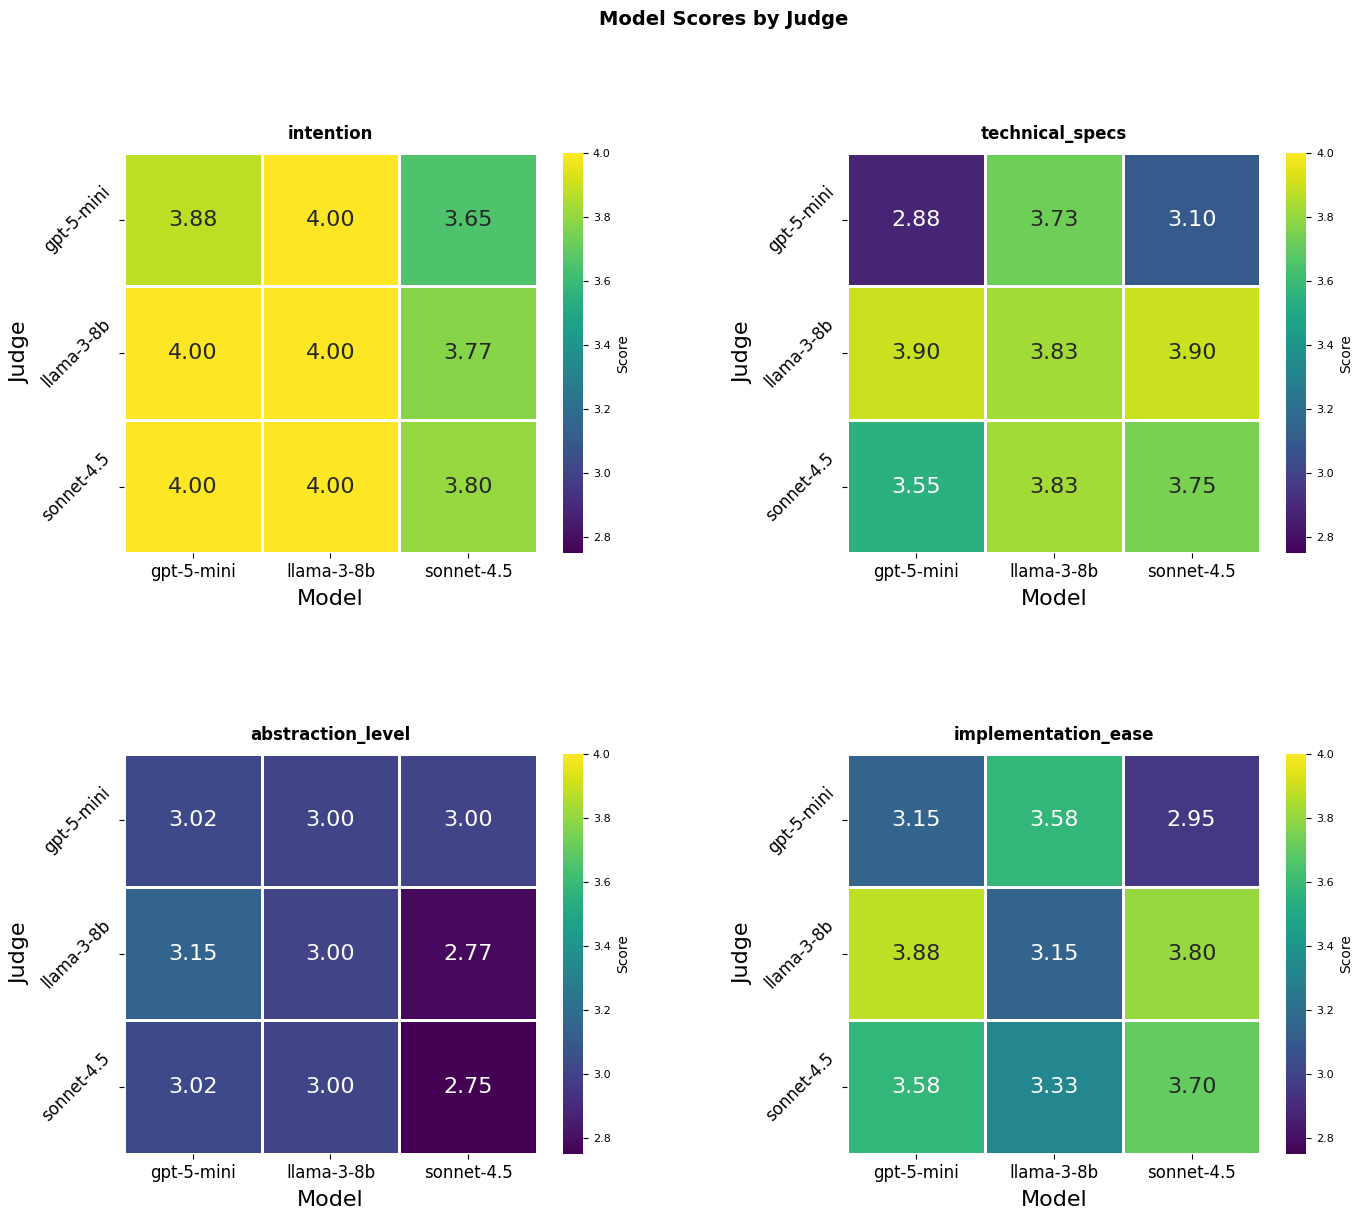

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

model_cols = ["sonnet-4.5", "gpt-5-mini", "llama-3-8b"]

pivots = [
    datasets[metric].group_by("judge")
    .agg([pl.col(c).mean() for c in model_cols])
    .to_pandas()
    .set_index("judge")
    .sort_index()
    .sort_index(axis=1)
    for metric in datasets
]

vmin = min(p.min().min() for p in pivots)
vmax = max(p.max().max() for p in pivots)

fig = plt.figure(figsize=(16, 13))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.4)

for idx, pivot, title in zip(range(4), pivots, datasets):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    
    hm = sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        linewidths=1,
        linecolor="white",
        cbar_kws={"label": "Score"},
        vmin=vmin, vmax=vmax,
        ax=ax,
        annot_kws={"size": 16},
    )
    
    hm.collections[0].colorbar.ax.tick_params(labelsize=8)
    
    ax.tick_params(axis="x", rotation=30, labelsize=12)
    ax.tick_params(axis="y", rotation=0, labelsize=12)

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Model", fontsize=16, labelpad=6)
    ax.set_ylabel("Judge", fontsize=16, labelpad=6)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=45)

plt.suptitle("Model Scores by Judge", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

In [39]:
from functools import reduce

reduce(
    lambda left, right: left.join(right, on="predictor-model", how="left"),
    [df.drop("judge").mean().transpose(include_header=True).rename({"column":"predictor-model", "column_0":metric}) for metric, df in datasets.items()]
)

predictor-model,intention,technical_specs,abstraction_level,implementation_ease
str,f64,f64,f64,f64
"""sonnet-4.5""",3.741667,3.583333,2.841667,3.483333
"""gpt-5-mini""",3.958333,3.441667,3.066667,3.533333
"""llama-3-8b""",4.0,3.791667,3.0,3.35
